# Dataset description
## External debt in USD and CHF

**Source**: Ministerio de Hacienda

**Download**: [link](https://www.irc.gov.co/deuda-publica/perfil-deuda-publica-gnc)

# Code
## Imports

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [175]:
logo_path = BASE_DIR / "logo/logo.png"
path = "./data/moneda_externa.csv"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,2,3,4,5,6])
logo = plt.imread(logo_path)

## Clean Data

In [176]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df[df["Fecha"].dt.year >= 2020]
df.set_index("Fecha", inplace=True)

non_zero_series = df[df["CHF"] != 0]
change = non_zero_series.index.min() - pd.Timedelta(days=30)

##  Plot

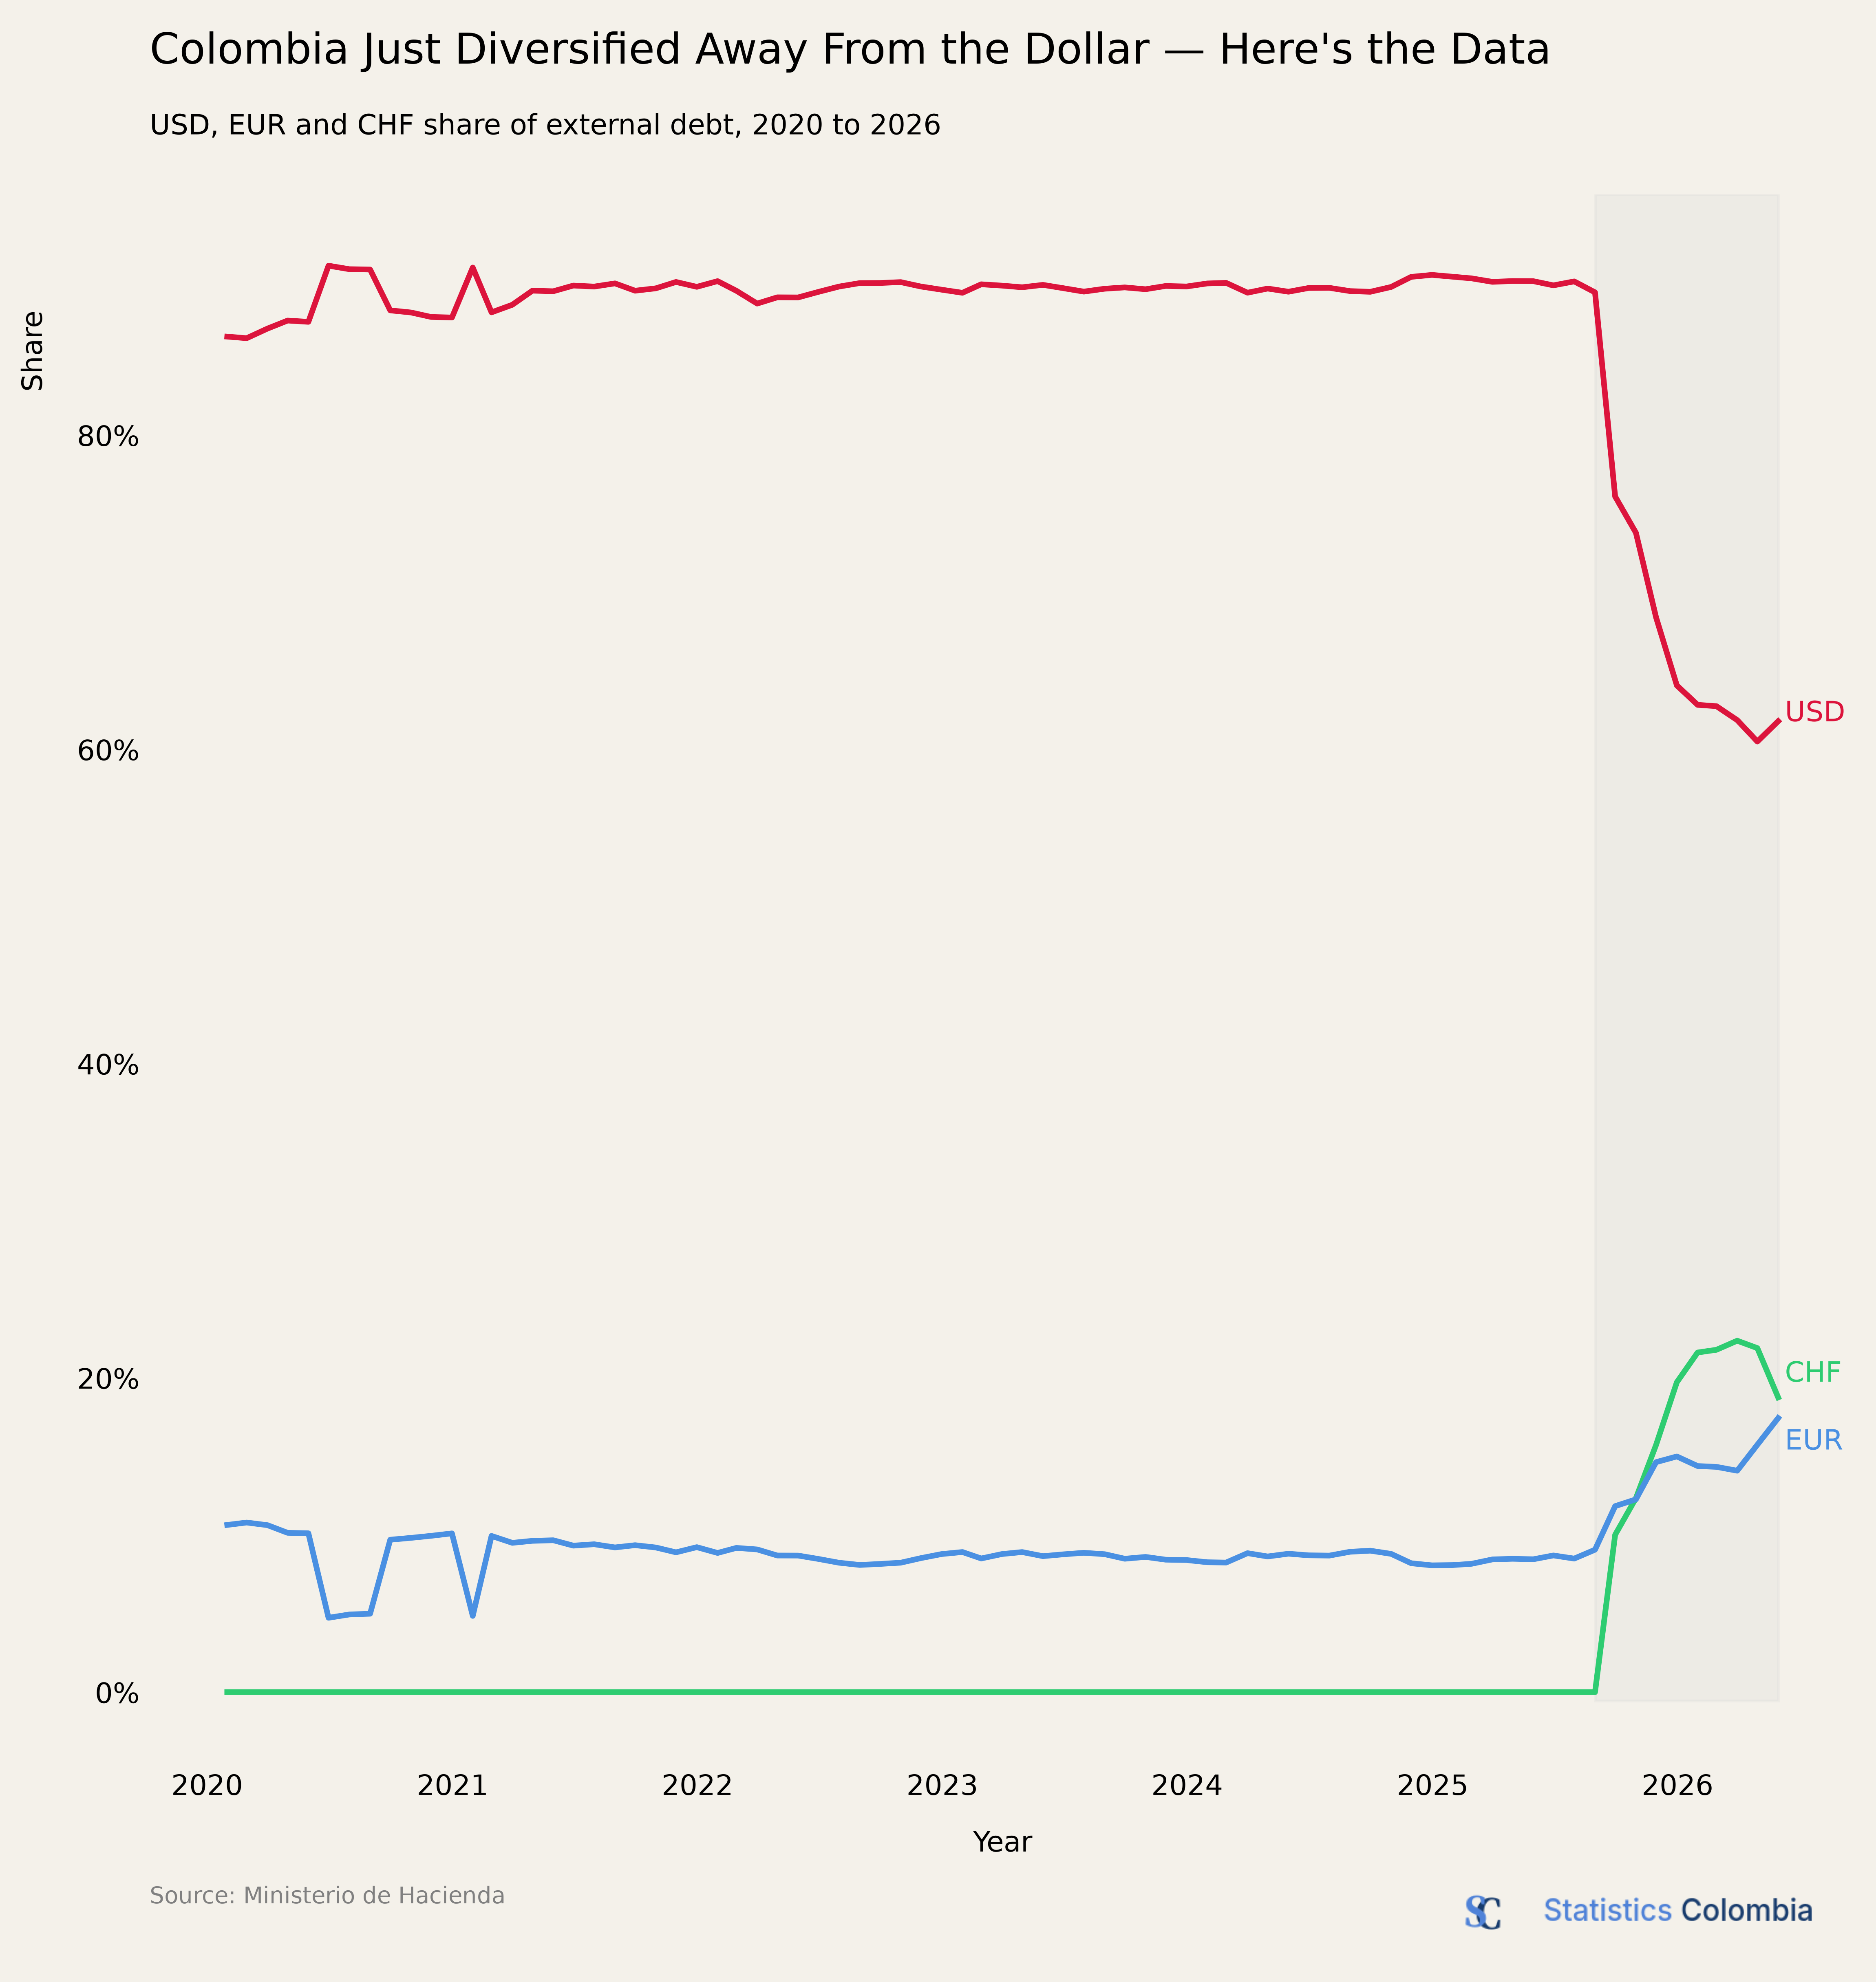

In [177]:
blue = "#4a90e2"
green = "#2ecc71"
gray = "#D3D3D3" 
red = "#DC143C"
background = "#F4F1EA"
x_axis = df.index

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(x_axis, df["CHF"], linewidth=2, color=green)
plt.plot(x_axis, df["USD"], linewidth=2, color=red)
plt.plot(x_axis, df["EUR"], linewidth=2, color=blue)

offset = pd.Timedelta(days=10)
last_date = x_axis[-1]
plt.text(last_date + offset, df.loc[last_date, "USD"], "USD", color=red)
plt.text(last_date + offset, df.loc[last_date, "CHF"] + 1, "CHF", color=green)
plt.text(last_date + offset, df.loc[last_date, "EUR"] - 2, "EUR", color=blue)

plt.axvspan(change, last_date, ymin=0.04, alpha=0.2, color=gray)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.xlabel("Year", labelpad=10, fontsize=10)
plt.ylabel("Share", labelpad=10, fontsize=10, y=0.9)

fig_text(
    x=0.125, y=0.96,
    s="Colombia Just Diversified Away From the Dollar — Here's the Data",
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="USD, EUR and CHF share of external debt, 2020 to 2026",
    fontsize=10
)

fig_text(
    0.125, 0.05, 
    "Source: Ministerio de Hacienda\n", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()